Dataset Found:
/kaggle/input/datasets/merajsharif/smart-city/smart_city_citizen_activity.csv

Dataset Shape:
(1000, 15)

RQ1 Table
Gender     Female  Male  Other
Age_Group                     
18-29        10.8  10.1    1.3
30-44        13.1  15.0    0.4
45-59        15.1  13.3    1.5
60+           9.4   9.1    0.9


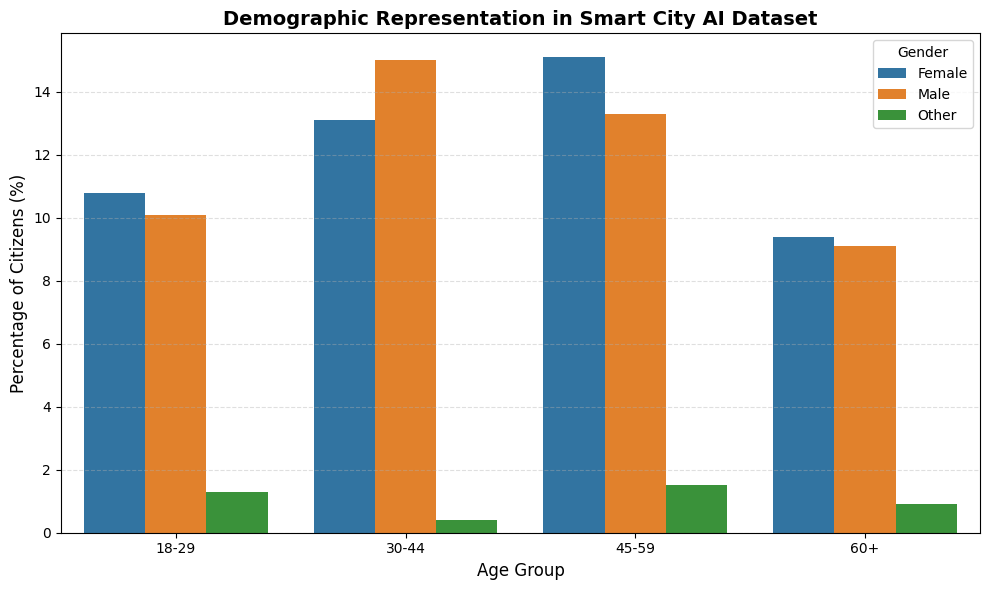


Files Generated:
RQ1_Age_Distribution.pdf
RQ1_Age_Distribution.png
RQ1_Demographic_Representation.csv
RQ1_Summary.csv

Download:
/kaggle/working/RQ1_Output.zip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil

citizen_file = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:

        if filename == "smart_city_citizen_activity.csv":

            citizen_file = os.path.join(
                dirname,
                filename
            )

print("Dataset Found:")
print(citizen_file)

citizen = pd.read_csv(citizen_file)

print("\nDataset Shape:")
print(citizen.shape)

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

bins = [18,30,45,60,100]

labels = [
    "18-29",
    "30-44",
    "45-59",
    "60+"
]

citizen["Age_Group"] = pd.cut(
    citizen["Age"],
    bins=bins,
    labels=labels,
    right=False
)

rq1_table = pd.crosstab(
    citizen['Age_Group'],
    citizen['Gender']
)

rq1_percent = (
    rq1_table / len(citizen) * 100
).round(2)

print("\nRQ1 Table")
print(rq1_percent)

# Save CSV

rq1_percent.to_csv(
    output_dir /
    "RQ1_Demographic_Representation.csv"
)

plot_df = rq1_percent.reset_index().melt(
    id_vars="Age_Group",
    var_name="Gender",
    value_name="Percentage"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df,
    x="Age_Group",
    y="Percentage",
    hue="Gender"
)

plt.title(
    "Demographic Representation in Smart City AI Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Age Group",
    fontsize=12
)

plt.ylabel(
    "Percentage of Citizens (%)",
    fontsize=12
)

plt.legend(
    title="Gender"
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

# SAVE PDF

plt.savefig(
    output_dir /
    "RQ1_Age_Distribution.pdf",
    dpi=600,
    bbox_inches="tight"
)

# SAVE PNG FOR POWERPOINT

plt.savefig(
    output_dir /
    "RQ1_Age_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


summary = pd.DataFrame({
    "Total_Citizens":[len(citizen)],
    "Male":[(citizen["Gender"]=="Male").sum()],
    "Female":[(citizen["Gender"]=="Female").sum()],
    "Other":[(citizen["Gender"]=="Other").sum()]
})

summary.to_csv(
    output_dir /
    "RQ1_Summary.csv",
    index=False
)

shutil.make_archive(
    "/kaggle/working/RQ1_Output",
    "zip",
    "outputs"
)

print("\nFiles Generated:")

for file in os.listdir("outputs"):
    print(file)

print("\nDownload:")
print("/kaggle/working/RQ1_Output.zip")